## Mooring Report, Lake Zug (29.07.26)

Longrange ADCP in middle of South basin.

In [7]:
# imports
import ewgreaders as ewg
import ewgdatsci as dsi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
lake = 'Zug'
date = '20260729'
loc = 'LZS'

di = ewg.get_data_index(lake, 'mooring')
di_sel = di[(di['date'] == date) & (di['location'] == loc)]

row = di_sel.iloc[0]
areader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
ds_adcp = areader.load()
ds_adcp = dsi.signal.valid_depths(ds_adcp, 0.9)

In [55]:
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)
x, y = mreader.get_swiss_coords(oom=False)
lat, lon = dsi.utils.ch1903_to_latlng(x, y)
f = dsi.efd.coriolis_frequency(lat)
f_hz = dsi.utils.angular_frequency_to_frequency(f)

### Velocity time series

In [56]:
u = ds_adcp.vel.sel(dir='E')
v = ds_adcp.vel.sel(dir='N')

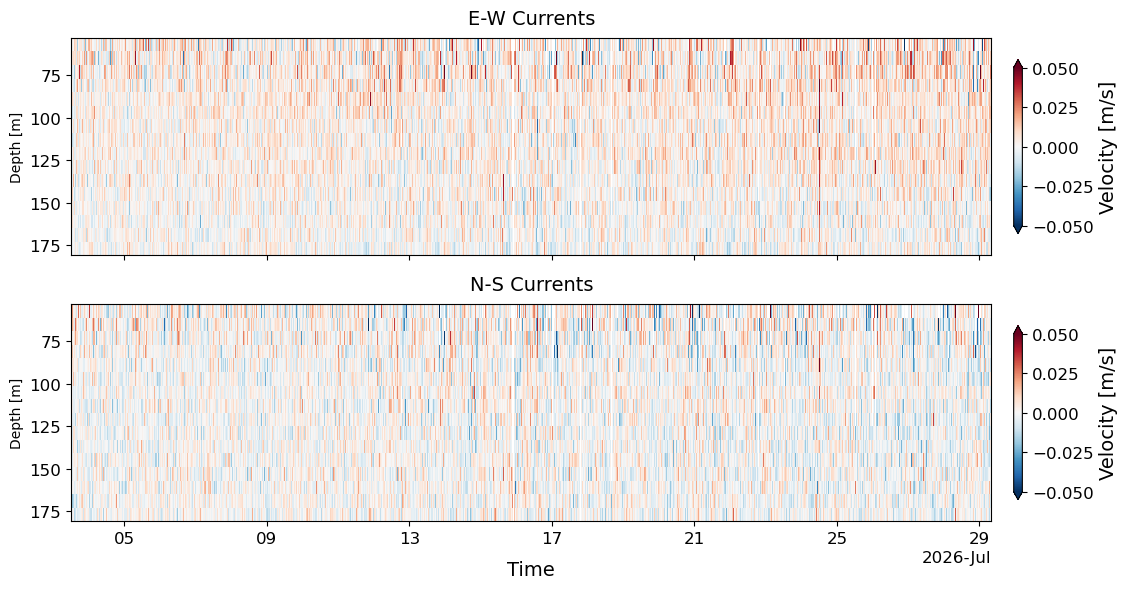

In [57]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True, sharey=True)

im = u.plot(cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink':0.8, 'pad': 0.02, 'label': r'Velocity [m/s]'}, ax=ax[0], rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

im = v.plot(cmap='RdBu_r', vmin=-0.05, vmax=0.05, cbar_kwargs={'shrink':0.8, 'pad': 0.02, 'label': r'Velocity [m/s]'}, ax=ax[1], rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

ax[0].set_xlabel('')
ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_title('E-W Currents', fontsize=14, pad=10)
ax[1].set_title('N-S Currents', fontsize=14, pad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)

ax[0].invert_yaxis()

plt.tight_layout()
plt.show()

### Poincare waves

In [58]:
rpsd = dsi.signal.rotary_psd_z(u, v, t_windows=True, window_hr=240, twfreq='1D', pandas=True)

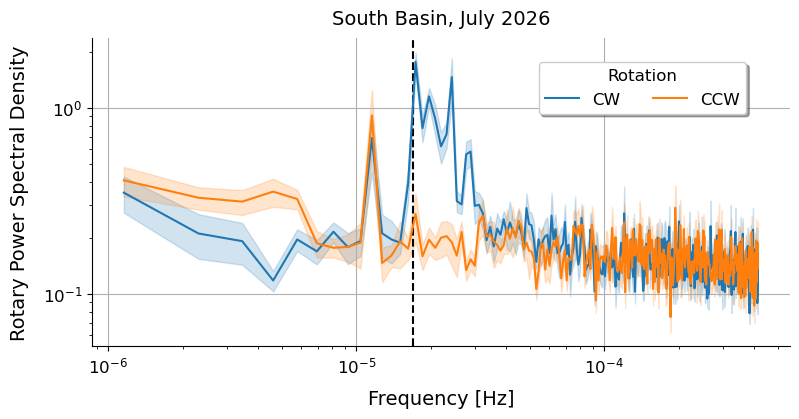

In [59]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.axvline(f_hz, color='black', linestyle='--')
sns.lineplot(rpsd, x='abs_frequency', y='rotary_power_spectral_density', hue='direction', errorbar=('se', 1), ax=ax)

ax.set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax.set_ylabel('Rotary Power Spectral Density', fontsize=14, labelpad=10)
ax.set_title('South Basin, July 2026', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(title='Rotation', fontsize=12, title_fontsize=12, ncols=2, shadow=True, loc='upper right', bbox_to_anchor=(0.95, 0.95))

plt.show()

### Spectral decomposition

In [65]:
psd = dsi.signal.psd_welch_z(v, window_hr=240, t_windows=True, twfreq='1D', pandas=True)

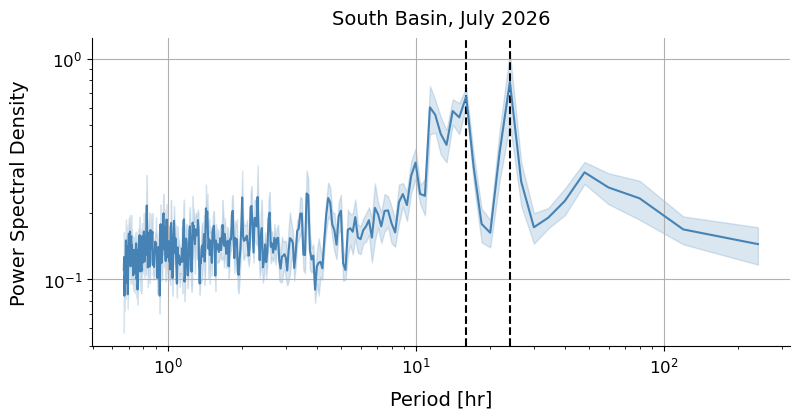

In [66]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.axvline(16, color='black', linestyle='--')
ax.axvline(24, color='black', linestyle='--')
sns.lineplot(psd, x='period', y='power_spectral_density', color='steelblue', errorbar=('se', 1), ax=ax)

ax.set_xlabel('Period [hr]', fontsize=14, labelpad=10)
ax.set_ylabel('Power Spectral Density', fontsize=14, labelpad=10)
ax.set_title('South Basin, July 2026', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.set_xscale('log')
ax.set_yscale('log')

plt.show()